In [80]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
from pathlib import Path

import sounddevice as sd

from scipy.signal import butter, sosfilt
from scipy.fft import fft, fftfreq

# Pretty plotss
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [21]:
#  Make dir to save waveforms
Path("waveforms").mkdir(exist_ok=True)
save_dir = Path("waveforms")

# Make Frequencies

In [120]:
sample_rate = 50000
duration_ms = 50
start_freq = 2000
end_freq = 25000
n_bins = 100

duration = duration_ms / 1000  # Convert ms to seconds
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Smooth sine envelope 
envelope = np.sin(np.pi * t / duration)

# Generate one .wav per frequency
frequencies = np.round(np.logspace(np.log10(start_freq), np.log10(end_freq), n_bins)).astype(int)
frequencies

array([ 2000,  2052,  2105,  2159,  2215,  2272,  2331,  2391,  2453,
        2516,  2581,  2648,  2716,  2787,  2859,  2932,  3008,  3086,
        3166,  3247,  3331,  3417,  3506,  3596,  3689,  3785,  3882,
        3983,  4086,  4191,  4300,  4411,  4525,  4642,  4762,  4885,
        5011,  5140,  5273,  5409,  5549,  5693,  5840,  5991,  6145,
        6304,  6467,  6634,  6806,  6981,  7162,  7347,  7537,  7732,
        7931,  8136,  8346,  8562,  8783,  9010,  9243,  9482,  9727,
        9978, 10236, 10501, 10772, 11051, 11336, 11629, 11930, 12238,
       12554, 12878, 13211, 13553, 13903, 14262, 14631, 15009, 15396,
       15794, 16202, 16621, 17051, 17491, 17943, 18407, 18883, 19371,
       19871, 20385, 20911, 21452, 22006, 22575, 23158, 23756, 24370,
       25000])

In [129]:
# Gen freqs
log = {}
for freq in frequencies:
    tone = np.sin(2 * np.pi * freq * t)
    signal = (tone * envelope).astype(np.float32)
    signal = (signal * 32767).astype(np.int16) # ADDED - check if works...

    log[freq] = {'tone': tone, 'envelope': envelope, 'signal': signal}

    

    # Stereo (duplicate to 2 channels)
    stereo = np.column_stack([signal, signal])

    wavfile.write(save_dir / f"{int(freq)}Hz.wav", sample_rate, stereo)

# save frequencies list
with open(save_dir / "frequencies.txt", "w") as f:
    for freq in frequencies:
        f.write(f"{freq}\n")

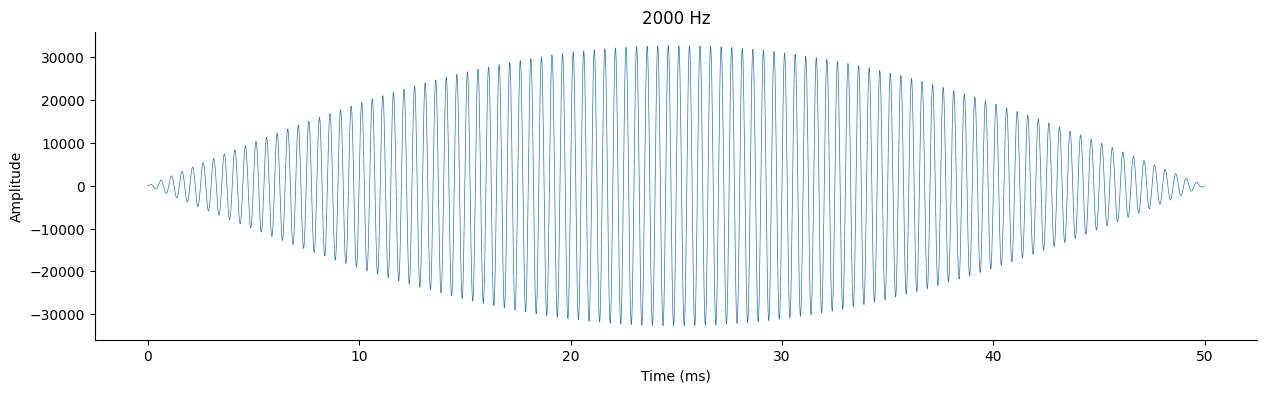

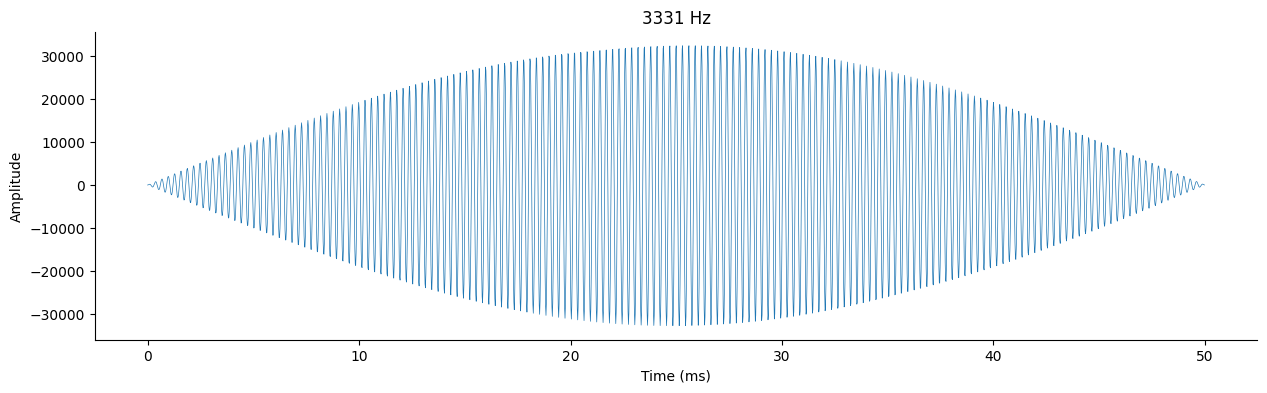

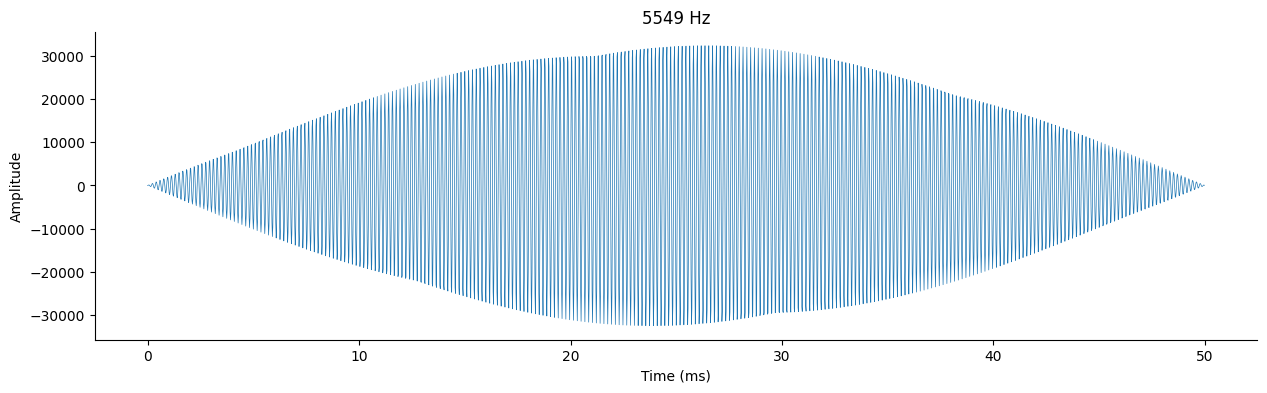

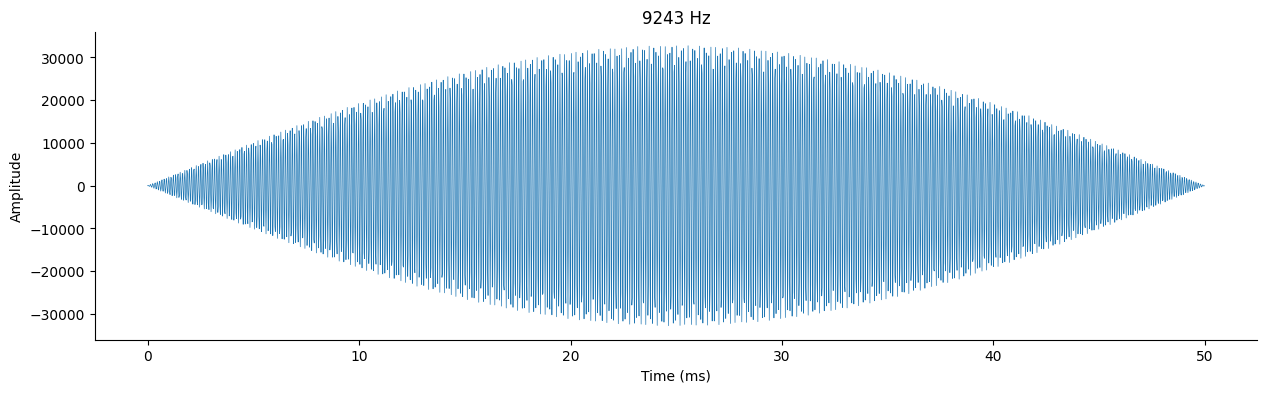

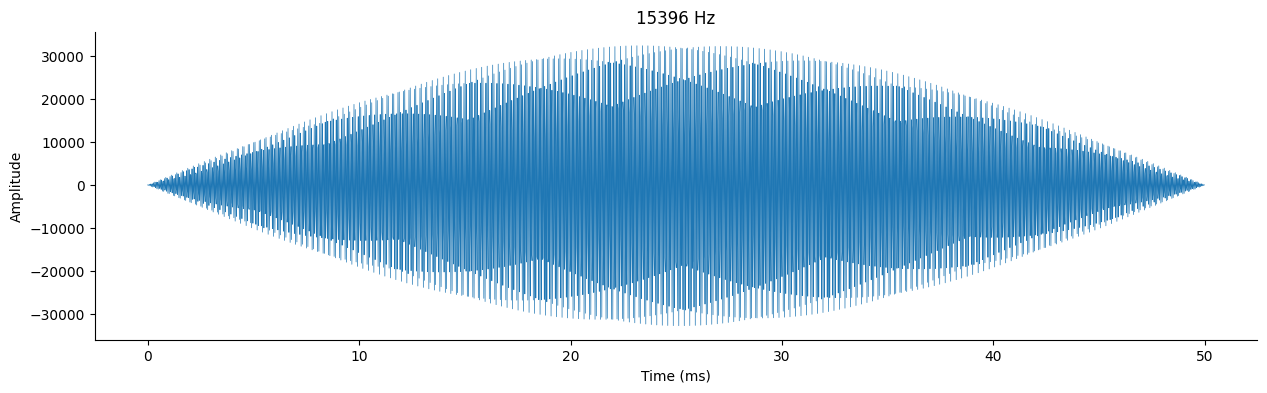

In [130]:
for freq in frequencies[::20]:
    plt.figure(figsize=(15, 4))
    plt.plot(t*1000, log[freq]['signal'], label=f'{freq} Hz', lw=0.5)
    plt.title(f'{freq} Hz')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')

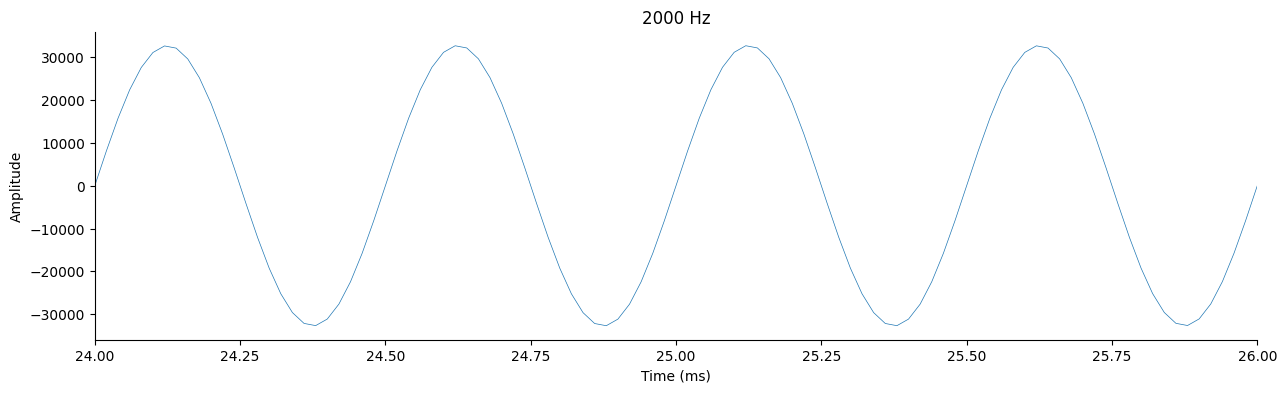

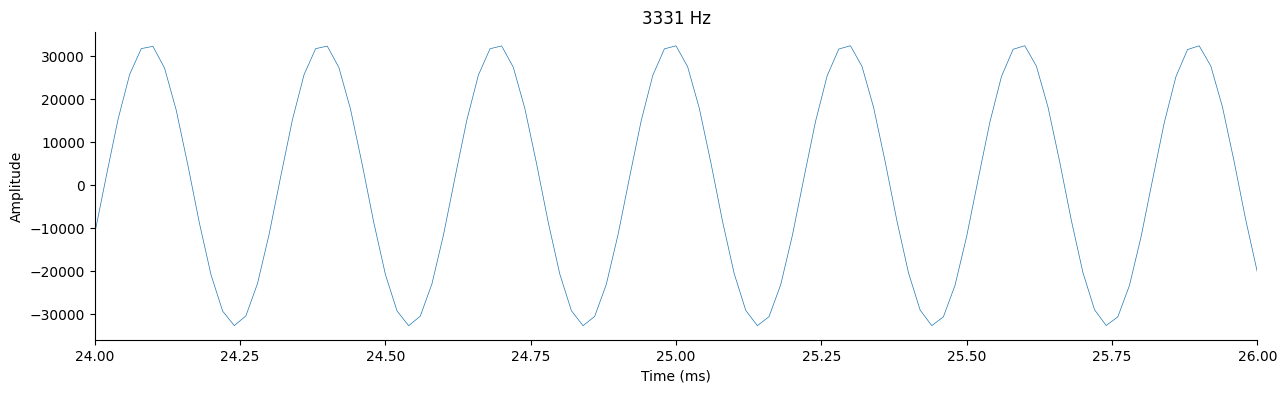

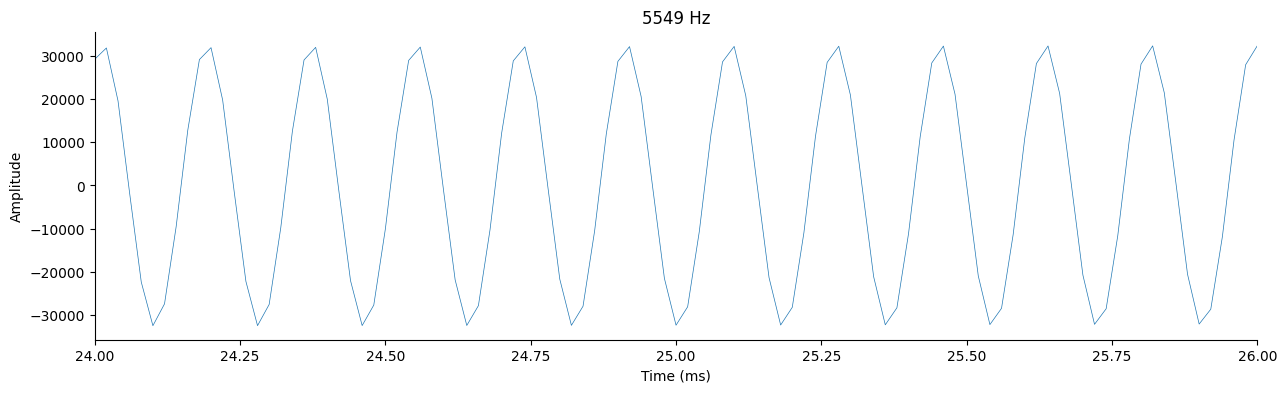

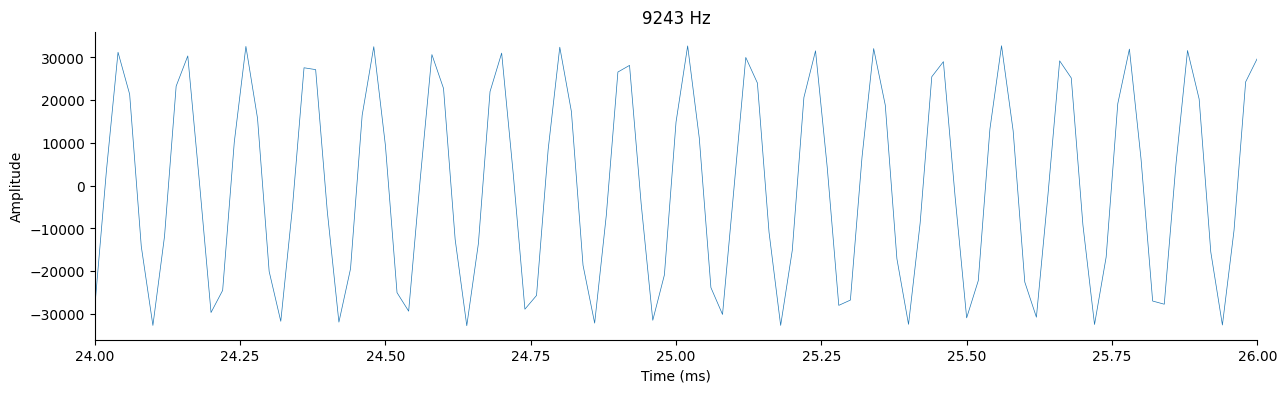

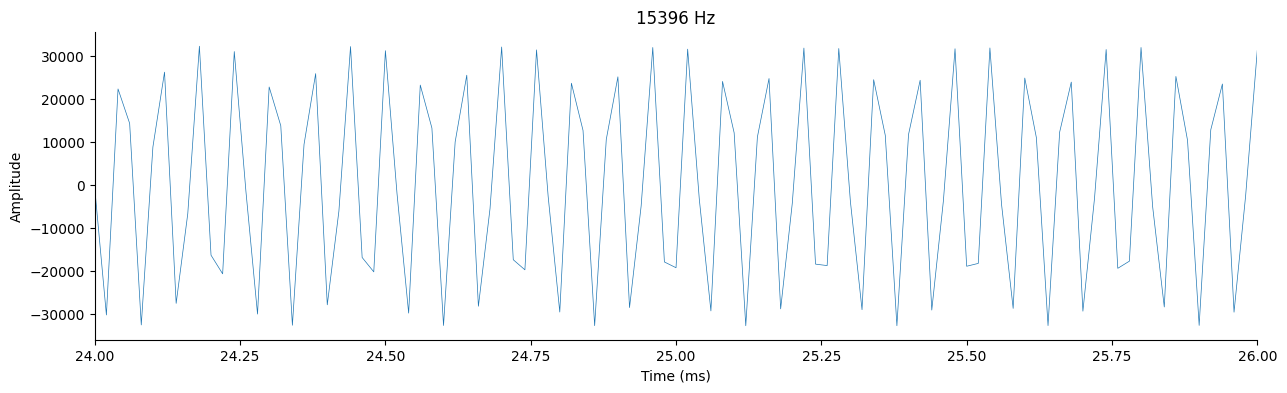

In [131]:
for freq in frequencies[::20]:
    plt.figure(figsize=(15, 4))
    plt.plot(t*1000, log[freq]['signal'], label=f'{freq} Hz', lw=0.5)
    plt.xlim(24, 26)
    plt.title(f'{freq} Hz')
    plt.xlabel('Time (ms)')
    plt.ylabel('Amplitude')

In [132]:
# Test play all freqs 
combined = np.concatenate([log[freq]['signal'] for freq in frequencies])
signal = np.column_stack([combined, combined])
sd.play(signal, sample_rate)
sd.wait()

## Make Whitenoise

In [133]:
# Make WN error tone
duration = 1 # seconds
sample_rate = 50000

low = frequencies[0]
high = frequencies[-1]
high = min(high, sample_rate / 2 - 1)

print(f"low: {low}, high: {high}, nyquist: {sample_rate/2}")

sos = butter(4, [float(low), float(high)], btype='band', fs=float(sample_rate), output='sos') 

noise = np.random.randn(int(sample_rate * duration)).astype(np.float64)
filtered = sosfilt(sos, noise).astype(np.float32)
filtered = filtered / np.max(np.abs(filtered))
filtered = (filtered * 32767).astype(np.int16)

# Save
wavfile.write(save_dir / "error_tone.wav", sample_rate, np.column_stack([filtered, filtered]))

low: 2000, high: 24999.0, nyquist: 25000.0


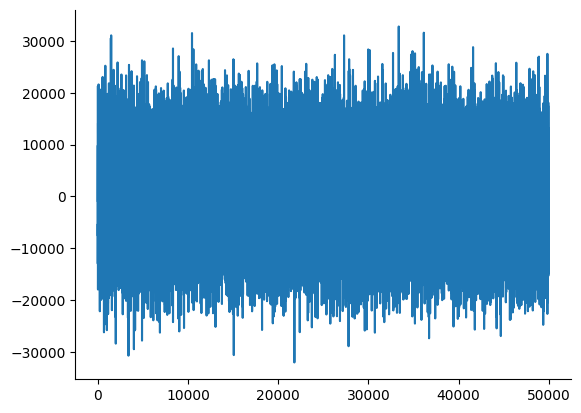

In [134]:
plt.plot(filtered);

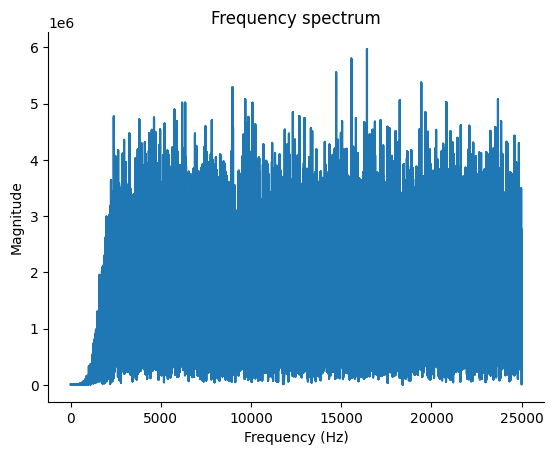

In [135]:
# Check WN spectrum
freqs = np.abs(fftfreq(len(filtered), 1/sample_rate))
spectrum = np.abs(fft(filtered))

plt.plot(freqs, spectrum)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency spectrum')
plt.show()

In [136]:
signal = np.column_stack([filtered, filtered])
sd.play(signal, sample_rate)
sd.wait()